In [1]:
import os
import re
import sys
import glob
import time
import intake
import intake_esm
import numpy as np
import pandas as pd
import scipy as io
import xarray as xr
import matplotlib.dates as mdates

from mpi4py import MPI
from datetime import date, datetime, timedelta
from matplotlib import pyplot as plt
from dask.distributed import Client
from xarray.coding.times import CFDatetimeCoder

time_coder = CFDatetimeCoder(use_cftime=True)

In [2]:
client = Client()
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 45475 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/45475/status,
Dashboard: /proxy/45475/status,Workers: 7
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40317,Workers: 0
Dashboard: /proxy/45475/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:46461,Total threads: 2
Dashboard: /proxy/45819/status,Memory: 9.00 GiB
Nanny: tcp://127.0.0.1:46879,


In [3]:
PAPA_DIR = "/g/data/jk72/ob1561"
papa_lw_file = os.path.join(PAPA_DIR, "lwnet50n145w_hr.cdf")

ds_lw = xr.open_dataset(papa_lw_file)

print(ds_lw)
print("\nData variables:", list(ds_lw.data_vars))
print("Coordinates:", list(ds_lw.coords))

print("\nLongwave variable details:")
for v in ds_lw.data_vars:
    print(f"\n--- {v} ---")
    print(ds_lw[v])
    print("Attrs:", ds_lw[v].attrs)
    print("Min / max (raw):",
          float(ds_lw[v].min()), float(ds_lw[v].max()))

ds_lw.close()

<xarray.Dataset> Size: 2MB
Dimensions:   (time: 138523, depth: 1, lat: 1, lon: 1)
Coordinates:
  * time      (time) datetime64[ns] 1MB 2010-01-01 ... 2025-10-20T18:00:00
  * depth     (depth) float32 4B 0.0
  * lat       (lat) float32 4B 50.0
  * lon       (lon) float32 4B 215.0
Data variables:
    LWN_1136  (time, depth, lat, lon) float32 554kB ...
    QLW_5136  (time, depth, lat, lon) float32 554kB ...
Attributes:
    platform_code:                50n145w
    site_code:                    50n145w
    array:                        TAO/TRITON
    Request_for_acknowledgement:  If you use these data in publications or pr...
    Data_Source:                  OCS Project Office/NOAA/PMEL
    OCS:                          Dr. Meghan F. Cronin: Meghan.F.Cronin@noaa.gov
    File_info:                    Contact: Dai.C.McClurg@noaa.gov
    missing_value:                1e+35
    _FillValue:                   1e+35
    CREATION_DATE:                16:32  7-DEC-2025

Data variables: ['LWN_1136'

In [4]:
print("Starting ACCESS-OM2 and Papa net longwave heat flux analysis.")
sys.stdout.flush()

catalog = intake.cat.access_nri

# -------------------------------------------------------------
# Date of interest
# -------------------------------------------------------------
start_date = np.datetime64("2010-01-01")
end_date = np.datetime64("2023-12-31")

# -------------------------------------------------------------
# Variable and degrees of interest in ACCESS-OM2
# -------------------------------------------------------------
var = "lw_heat"
experiments = [
    "1deg_jra55_iaf_omip2_cycle6",
    "025deg_jra55_iaf_omip2_cycle6",
    ["01deg_jra55v140_iaf_cycle4", "01deg_jra55v140_iaf_cycle4_jra55v150_extension"],
]

# Papa
PAPA_DIR = "/g/data/jk72/ob1561"
papa_lw_file = os.path.join(PAPA_DIR, "lwnet50n145w_hr.cdf")
papa_var = "LWN_1136"   # from your inspection cell

# -------------------------------------------------------------
# Region of interest (unchanged)
# -------------------------------------------------------------
region_lat = np.array([49, 51])      # narrow 2° band around 50°N
region_lon = np.array([213, 217])# xt_ocean, E     # -> [-215, -210]
region_lon = region_lon - 360
region = [region_lat, region_lon]

Starting ACCESS-OM2 and Papa net longwave heat flux analysis.


In [5]:
#----------------------------------------------------------------------------------------------
# This section collects all the experiment / degrees / variable paths
#----------------------------------------------------------------------------------------------
print(f'Processing ACCESS {var} data...')
sys.stdout.flush()
    

path_dict = {}

catalogs = []

for exp in experiments:

    if isinstance(exp, list):  # both tenth degree + extention
        merged_name = exp[0]   
        path_dict[merged_name] = []
    
        for subexp in exp:
            filtered = catalog[subexp].search(
                variable=var,
                frequency='1mon',
                realm='ocean',
            )
            df = filtered.df
            df['start_date'] = pd.to_datetime(df['start_date'])
            df['end_date']   = pd.to_datetime(df['end_date'])
    
            df = df[
                (df['start_date'] >= np.datetime64("2010-01-01")) &
                (df['end_date']   <= np.datetime64("2023-12-31"))
            ]
    
            file_list = df['path'].tolist()
            path_dict[merged_name].extend(file_list)
    
        print(f"{merged_name}: {len(path_dict[merged_name])} files")
    
    else:  
        path_dict[exp] = []
        filtered = catalog[exp].search(
            variable=var,
            frequency='1mon',
            realm='ocean',
        )
        df = filtered.df
        df['start_date'] = pd.to_datetime(df['start_date'])
        df['end_date']   = pd.to_datetime(df['end_date'])
    
        df = df[
            (df['start_date'] >= np.datetime64("2010-01-01")) &
            (df['end_date']   <= np.datetime64("2023-12-31"))
        ]
    
        file_list = df['path'].tolist()
        path_dict[exp].extend(file_list)
    
        print(f"{exp}: {len(file_list)} files")
    



Processing ACCESS lw_heat data...
1deg_jra55_iaf_omip2_cycle6: 8 files
025deg_jra55_iaf_omip2_cycle6: 8 files
01deg_jra55v140_iaf_cycle4: 167 files


In [15]:
#----------------------------------------------------------------------------------------------
# Collect ACCESS data
#----------------------------------------------------------------------------------------------

exp_heat_flux = {} #dict for each deg

start = time.time()

exp_heat_flux = {}

experiments = [
    "1deg_jra55_iaf_omip2_cycle6",
    "025deg_jra55_iaf_omip2_cycle6",
    "01deg_jra55v140_iaf_cycle4"
]

for exp in experiments:
    print(f"Start collecting {var} {exp} data for ACCESS.")
    sys.stdout.flush()
    start = time.time()

    path_list = path_dict[exp]

    ds = xr.open_mfdataset(
        path_list,
        combine="nested",
        concat_dim="time",
        data_vars="minimal",
        coords="minimal",
        decode_timedelta=True
    )

    # Only sort time for tenth deg 
    if "01deg" in exp:
        ds = ds.sortby("time")

    # Slice region and time
    heat_flux = ds[var].sel(
        time=slice(start_date, end_date),
        yt_ocean=slice(region[0][0], region[0][1]),
        xt_ocean=slice(region[1][0], region[1][1])
    ).mean(dim=["yt_ocean", "xt_ocean"])

    ds.close()

    # Keep units
    units = heat_flux.attrs.get("units", "")
    heat_flux.attrs["units"] = units

    grp = heat_flux.groupby("time.month")
    monthly_mean = grp.mean("time", skipna=True)
    monthly_std  = grp.std("time", skipna=True)
    monthly_n    = grp.count("time")
    monthly_sem  = monthly_std / np.sqrt(monthly_n)
    
    exp_heat_flux[exp] = {
    "monthly_mean": monthly_mean,
    "monthly_sem": monthly_sem
}

    end = time.time()
    print(f"Finished collecting {var} data for ACCESS.")
    sys.stdout.flush()
    print(f"Execution time: {(end - start)/60:.2f} minutes")
    sys.stdout.flush()


Start collecting lw_heat 1deg_jra55_iaf_omip2_cycle6 data for ACCESS.
Finished collecting lw_heat data for ACCESS.
Execution time: 0.03 minutes
Start collecting lw_heat 025deg_jra55_iaf_omip2_cycle6 data for ACCESS.
Finished collecting lw_heat data for ACCESS.
Execution time: 0.04 minutes
Start collecting lw_heat 01deg_jra55v140_iaf_cycle4 data for ACCESS.
Finished collecting lw_heat data for ACCESS.
Execution time: 0.05 minutes


In [16]:
#--------------------------------------------------------------
# Read and collect data for Papa (net longwave radiation)
#--------------------------------------------------------------

print(f"Processing Papa {var} data...")
sys.stdout.flush()

# File and variable were defined in the config cell
#   papa_lw_file = "/g/data/jk72/ob1561/lwnet50n145w_hr.cdf"
#   papa_var     = "LWN_1136"

start = time.time()

# Open the Papa longwave dataset
ds_papa = xr.open_dataset(papa_lw_file)

# Extract the net longwave variable
papa_lw = papa_lw.where(np.isfinite(papa_lw))
papa_lw = papa_lw.where(papa_lw < 1e20)

# Replace missing values (1e35 → NaN)
#papa_lw = papa_lw.where(papa_lw < 1e20)

# Compute monthly climatology
grp = papa_lw.groupby("time.month")

papa_monthly_mean = grp.mean("time", skipna=True).squeeze()
papa_monthly_std  = grp.std("time", skipna=True).squeeze()
papa_monthly_n    = grp.count("time").squeeze()
papa_monthly_sem  = papa_monthly_std / np.sqrt(papa_monthly_n)

ds_papa.close()

print(papa_monthly_climatology)

end = time.time()
print(f"Finished collecting Papa {var} data.")
sys.stdout.flush()
print(f"Execution time: {(end - start)/60:.2f} minutes")
sys.stdout.flush()

Processing Papa lw_heat data...
<xarray.DataArray 'LWN_1136' (month: 12)> Size: 48B
array([37.6211  , 36.067158, 42.269447, 36.145752, 25.232077, 19.070627,
       13.46629 , 21.021494, 36.9837  , 43.090958, 45.623867, 42.327045],
      dtype=float32)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    depth    float32 4B 0.0
    lat      float32 4B 50.0
    lon      float32 4B 215.0
Attributes:
    name:            LWN
    long_name:       NET LONGWAVE RADIATION
    generic_name:    qln
    FORTRAN_format:   
    units:           W m-2
    epic_code:       1136
Finished collecting Papa lw_heat data.
Execution time: 0.00 minutes


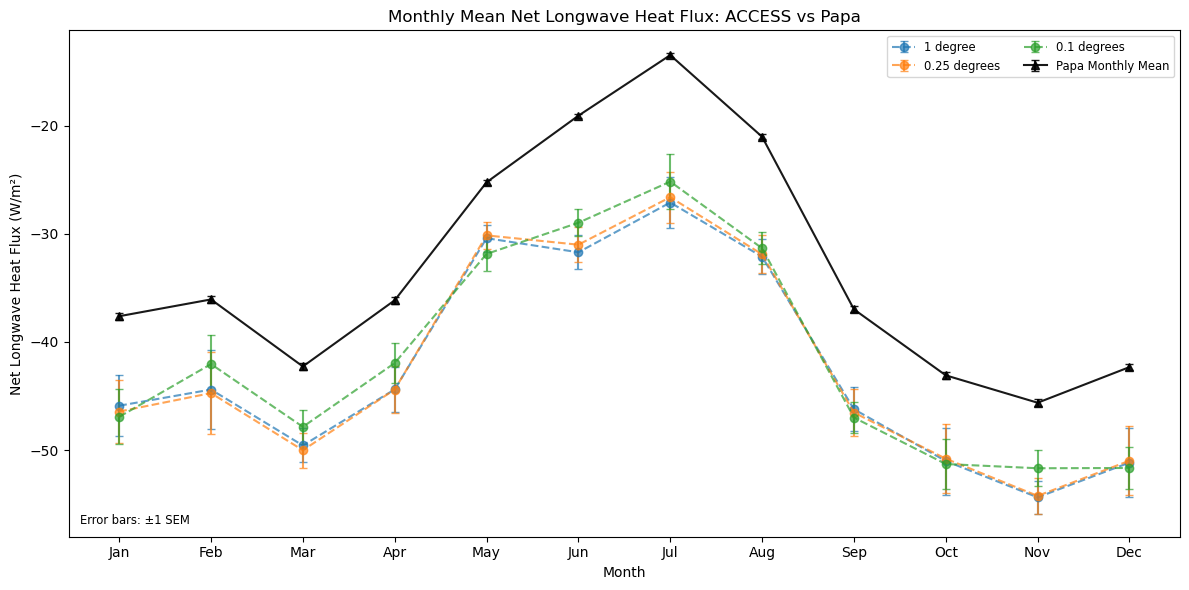

In [18]:
#--------------------------------------------------------------
# PLOT
#--------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))

exp_titles = {
    "1deg_jra55_iaf_omip2_cycle6": "1 degree",
    "025deg_jra55_iaf_omip2_cycle6": "0.25 degrees",
    "01deg_jra55v140_iaf_cycle4": "0.1 degrees",
}

# ---- ACCESS curves (unchanged) ----
for exp_name, data_dict in exp_heat_flux.items():
    monthly_mean = data_dict["monthly_mean"]
    monthly_sem  = data_dict["monthly_sem"]
    label = exp_titles.get(exp_name, exp_name)

    ax.errorbar(
        monthly_mean["month"],
        monthly_mean.values,
        yerr=monthly_sem.values,
        marker="o",
        linestyle="--",
        alpha=0.7,
        capsize=3,
        label=label
    )

# ---- Papa longwave curve (replaces SOTS) ----
# Papa LWN_1136 is positive downward; ACCESS lw_heat is positive upward,
# so we multiply by -1 to put them on the same sign convention.
ax.errorbar(
    papa_monthly_mean["month"],
    -1*papa_monthly_mean.values,
    yerr=papa_monthly_sem.values,
    color="black",
    marker="^",
    linestyle="-",
    alpha=0.9,
    capsize=3,
    label="Papa Monthly Mean"
)


ax.set_xlabel("Month")
ax.set_ylabel("Net Longwave Heat Flux (W/m²)")
ax.set_title("Monthly Mean Net Longwave Heat Flux: ACCESS vs Papa")

ax.set_xticks(np.arange(1, 13))
ax.set_xticklabels(
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)

ax.legend(ncol=2, fontsize="small", loc="best")
ax.text(
    0.01, 0.02,
    "Error bars: ±1 SEM",
    transform=ax.transAxes,
    fontsize="small",
    ha="left",
    va="bottom"
)
plt.tight_layout()
plt.show()

In [12]:
print("raw min/max:", float(heat_flux.min()), float(heat_flux.max()))

raw min/max: -65.17452239990234 -3.762465000152588
